# 🧹 Data Cleaning — Dataset OCR Informasi Gizi
> Membersihkan dataset gambar crop dan menyinkronkan CSV label.

**Yang dilakukan notebook ini:**
- ✅ Hapus gambar terlalu gelap / overexposed
- ✅ Hapus gambar blur berat (tidak terbaca)
- ✅ Sharpen gambar blur ringan
- ✅ Resize semua gambar ke tinggi 64px (standar CRNN)
- ✅ Pertahankan gambar aspek ratio ekstrem (CRNN handle via CTC)
- ✅ Buat CSV baru hanya berisi gambar yang lolos

**Data asli TIDAK diubah.** Hasil disimpan ke folder `cleaned/` yang baru.

## 0. Mount Drive & Install

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!pip install opencv-python pandas openpyxl tqdm -q
print('✅ Siap')

Mounted at /content/drive
✅ Siap


## 1. Konfigurasi

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

# ── PATH ──────────────────────────────────────────────────────
IMG_DIR    = '/content/drive/MyDrive/ocr_crop_v3/test'     # folder gambar asli
VALID_DIR  = '/content/drive/MyDrive/ocr_crop_v3/valid'    # folder excel asli
OUTPUT_IMG = '/content/drive/MyDrive/ocr_crop_v3/cleaned/images'   # output gambar bersih
OUTPUT_CSV = '/content/drive/MyDrive/ocr_crop_v3/cleaned/labels.csv'  # output csv bersih
OUTPUT_LOG = '/content/drive/MyDrive/ocr_crop_v3/cleaned/removed_log.csv'  # log gambar dihapus

os.makedirs(OUTPUT_IMG, exist_ok=True)
os.makedirs(str(Path(OUTPUT_CSV).parent), exist_ok=True)

# ── THRESHOLD ─────────────────────────────────────────────────
BLUR_REMOVE    = 15    # blur score < ini → hapus (benar-benar tidak terbaca)
BLUR_SHARPEN   = 50    # blur score 15–50 → sharpen lalu pertahankan
BRIGHTNESS_LOW  = 30   # brightness < ini → hapus (terlalu gelap)
BRIGHTNESS_HIGH = 225  # brightness > ini → hapus (overexposed)
# Aspek ratio ekstrem: TIDAK dihapus, CRNN handle via CTC Loss

TARGET_HEIGHT  = 64    # tinggi standar CRNN (px)

print('✅ Konfigurasi selesai')
print(f'   Blur hapus    : < {BLUR_REMOVE}')
print(f'   Blur sharpen  : {BLUR_REMOVE} – {BLUR_SHARPEN}')
print(f'   Brightness    : {BRIGHTNESS_LOW} – {BRIGHTNESS_HIGH}')
print(f'   Target height : {TARGET_HEIGHT}px')

✅ Konfigurasi selesai
   Blur hapus    : < 15
   Blur sharpen  : 15 – 50
   Brightness    : 30 – 225
   Target height : 64px


## 2. Load Label Excel

In [3]:
excel_files = list(Path(VALID_DIR).glob('*.xlsx')) + list(Path(VALID_DIR).glob('*.xls'))

if not excel_files:
    raise FileNotFoundError(f'❌ Tidak ada file Excel di: {VALID_DIR}')

df = pd.read_excel(excel_files[0])
df.columns = df.columns.str.strip().str.lower()

# Validasi kolom wajib
for col in ['file_name', 'text']:
    if col not in df.columns:
        raise ValueError(f'❌ Kolom "{col}" tidak ditemukan. Kolom tersedia: {list(df.columns)}')

# Buang baris dengan label kosong
before = len(df)
df = df[df['text'].notna() & (df['text'].astype(str).str.strip() != '')].reset_index(drop=True)
after = len(df)

print(f'✅ Excel dimuat: {excel_files[0].name}')
print(f'   Total baris        : {before}')
print(f'   Label kosong dibuang: {before - after}')
print(f'   Baris valid         : {after}')
df.head()

✅ Excel dimuat: valid.xlsx
   Total baris        : 2490
   Label kosong dibuang: 0
   Baris valid         : 2490


,file_name,text
0,calories_0002.png,Energi Total 151 kkal 69 kcal
1,calories_0010.png,Energi Total 70 kkal
2,calories_0040.png,Energi Total 100 kkal
3,calories_0041.png,Energi Total 90 kkal
4,calories_0043.png,Energi Total 80 kkal


## 3. Fungsi Pembantu

In [4]:
def laplacian_var(gray):
    """Mengukur ketajaman. Makin rendah = makin blur."""
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def sharpen(img):
    """Sharpening kernel 3x3."""
    kernel = np.array([[ 0, -1,  0],
                       [-1,  5, -1],
                       [ 0, -1,  0]])
    return cv2.filter2D(img, -1, kernel)

def resize_keep_aspect(img, target_h):
    """Resize ke tinggi target, lebar proporsional."""
    h, w = img.shape[:2]
    scale = target_h / h
    new_w = max(1, int(w * scale))
    return cv2.resize(img, (new_w, target_h), interpolation=cv2.INTER_AREA)

print('✅ Fungsi siap')

✅ Fungsi siap


## 4. Proses Cleaning

In [5]:
kept      = []   # list dict {file_name, text} yang lolos
removed   = []   # list dict {file_name, reason} yang dihapus
sharpened = []   # list file_name yang di-sharpen

print('Memulai cleaning...\n')

for _, row in tqdm(df.iterrows(), total=len(df), desc='Cleaning'):
    fname = str(row['file_name']).strip()
    label = str(row['text']).strip()
    fpath = os.path.join(IMG_DIR, fname)

    # ── Cek file ada ──────────────────────────────────────────
    if not os.path.exists(fpath):
        removed.append({'file_name': fname, 'reason': 'file_tidak_ditemukan'})
        continue

    # ── Baca gambar ───────────────────────────────────────────
    img = cv2.imread(fpath)
    if img is None:
        removed.append({'file_name': fname, 'reason': 'corrupt_tidak_terbaca'})
        continue

    h, w  = img.shape[:2]
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur  = laplacian_var(gray)
    bright = gray.mean()

    # ── HAPUS: terlalu gelap atau overexposed ─────────────────
    if bright < BRIGHTNESS_LOW:
        removed.append({'file_name': fname, 'reason': f'terlalu_gelap(brightness={bright:.1f})'})
        continue

    if bright > BRIGHTNESS_HIGH:
        removed.append({'file_name': fname, 'reason': f'overexposed(brightness={bright:.1f})'})
        continue

    # ── HAPUS: blur berat ─────────────────────────────────────
    if blur < BLUR_REMOVE:
        removed.append({'file_name': fname, 'reason': f'blur_berat(score={blur:.1f})'})
        continue

    # ── SHARPEN: blur ringan ──────────────────────────────────
    if blur < BLUR_SHARPEN:
        img = sharpen(img)
        sharpened.append(fname)

    # ── RESIZE ke tinggi 64px, lebar proporsional ─────────────
    # Aspek ratio ekstrem TIDAK dihapus, langsung diproses
    img = resize_keep_aspect(img, TARGET_HEIGHT)

    # ── SIMPAN gambar ke folder cleaned ──────────────────────
    out_path = os.path.join(OUTPUT_IMG, fname)
    cv2.imwrite(out_path, img)
    kept.append({'file_name': fname, 'text': label})

print('\n✅ Proses selesai!')

Memulai cleaning...



Cleaning:   0%|          | 0/2490 [00:00<?, ?it/s]


✅ Proses selesai!


## 5. Simpan CSV Bersih & Log

In [6]:
# ── Simpan CSV bersih ─────────────────────────────────────────
df_clean = pd.DataFrame(kept, columns=['file_name', 'text'])
df_clean.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')

# ── Simpan log gambar yang dihapus ────────────────────────────
df_removed = pd.DataFrame(removed, columns=['file_name', 'reason'])
df_removed.to_csv(OUTPUT_LOG, index=False, encoding='utf-8-sig')

print('='*52)
print('  RINGKASAN HASIL CLEANING')
print('='*52)
print(f'  Total input          : {len(df)} gambar')
print(f'  Gambar dipertahankan : {len(kept)}')
print(f'  Gambar di-sharpen    : {len(sharpened)}')
print(f'  Gambar dihapus       : {len(removed)}')
print(f'  ─────────────────────────────────────')

# Detail alasan dihapus
if removed:
    reason_summary = df_removed['reason'].str.extract(r'^(\w+)')[0].value_counts()
    print(f'  Detail dihapus:')
    for reason, count in reason_summary.items():
        print(f'    - {reason:30s}: {count}')

print(f'\n  📁 Output folder  : .../cleaned/')
print(f'  📄 CSV bersih     : labels.csv ({len(kept)} baris)')
print(f'  📄 Log dihapus    : removed_log.csv ({len(removed)} baris)')

  RINGKASAN HASIL CLEANING
  Total input          : 2490 gambar
  Gambar dipertahankan : 2391
  Gambar di-sharpen    : 409
  Gambar dihapus       : 99
  ─────────────────────────────────────
  Detail dihapus:
    - blur_berat                    : 67
    - overexposed                   : 29
    - terlalu_gelap                 : 3

  📁 Output folder  : .../cleaned/
  📄 CSV bersih     : labels.csv (2391 baris)
  📄 Log dihapus    : removed_log.csv (99 baris)


## 6. Verifikasi Hasil

Jumlah file gambar di cleaned/images : 2391
Jumlah baris di labels.csv           : 2391
Sinkron: ✅ YA


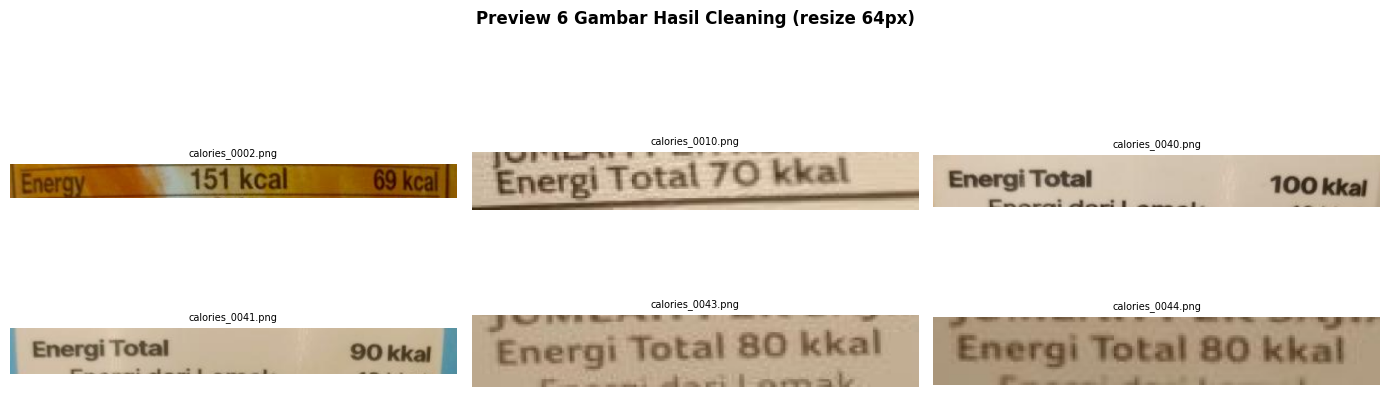

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Cek jumlah file di folder cleaned vs jumlah baris CSV
n_files = len(list(Path(OUTPUT_IMG).glob('*.png'))) + \
          len(list(Path(OUTPUT_IMG).glob('*.jpg'))) + \
          len(list(Path(OUTPUT_IMG).glob('*.jpeg')))

n_csv = len(pd.read_csv(OUTPUT_CSV))

print(f'Jumlah file gambar di cleaned/images : {n_files}')
print(f'Jumlah baris di labels.csv           : {n_csv}')
print(f'Sinkron: {"✅ YA" if n_files == n_csv else "❌ TIDAK SAMA — cek log"}')

# Preview 6 gambar hasil cleaning
sample_files = list(Path(OUTPUT_IMG).glob('*.png'))[:6]
if not sample_files:
    sample_files = list(Path(OUTPUT_IMG).glob('*.jpg'))[:6]

if sample_files:
    fig, axes = plt.subplots(2, 3, figsize=(14, 5))
    fig.suptitle('Preview 6 Gambar Hasil Cleaning (resize 64px)', fontweight='bold')
    for ax, fpath in zip(axes.flat, sample_files):
        img = mpimg.imread(str(fpath))
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.set_title(fpath.name, fontsize=7)
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('Tidak ada gambar untuk preview.')

---
## Catatan untuk AI Engineer

| Item | Nilai |
|---|---|
| Folder gambar bersih | `cleaned/images/` |
| File label | `cleaned/labels.csv` |
| Log gambar dihapus | `cleaned/removed_log.csv` |
| Tinggi gambar | **64px**, lebar proporsional |
| Format label | `file_name, text` |
| Normalisasi | Belum — lakukan saat DataLoader (bagi 255.0) |
| CTC Loss | Wajib, karena lebar gambar bervariasi |
| Split dataset | 80% train / 10% val / 10% test (stratified per kelas) |